<a href="https://colab.research.google.com/github/venkateshbingi1005/TensorFlow/blob/main/1.%20Sequential_Functional_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### TF 2 and Keras (Sequential API)

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [3]:
print(tf.__version__)

2.18.0


In [54]:
# load mnist dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [55]:
print('x_train: ',x_train.shape)
print('y_train: ',y_train.shape)
print('x_test: ',x_test.shape)
print('y_test: ',y_test.shape)

x_train:  (60000, 28, 28)
y_train:  (60000,)
x_test:  (10000, 28, 28)
y_test:  (10000,)


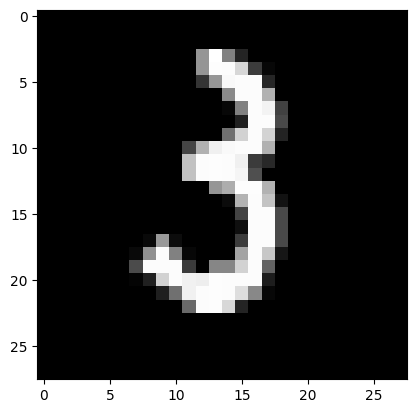

In [56]:
idx = 1234
plt.imshow(x_train[idx], cmap='gray', interpolation='none')
plt.show()

In [64]:
# number of class labels
num_labels = len(np.unique(y_train))
num_labels

10

In [65]:
# convert y_i's to one-hot vectors
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [66]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [67]:
x_train.shape

(60000, 28, 28)

In [68]:
# Image: 2D matrix to 1D vector
image_size = x_train.shape[1] # 28
input_size = image_size * image_size #28*28=784

# 2D to 1D + Normalize (0-255)
x_train = np.reshape(x_train, [-1,input_size])
x_train = x_train.astype('float32') / 255
x_test = np.reshape(x_test, [-1,input_size])
x_test = x_test.astype('float32') / 255

In [69]:
x_train.shape, x_test.shape

((60000, 784), (10000, 784))

In [70]:
# Hyder-params of NN
batch_size = 128 # typically 2^n
hidden_units = 256

In [71]:
# Sequential API

# 3-layer MLP with ReLU
model = Sequential()
# model.add(Dense(hidden_units, input_dim=input_size)) # throws a warning
model.add(layers.Input(shape=(input_size,)))
model.add(Dense(hidden_units))
model.add(Activation('relu'))
model.add(Dense(hidden_units))
model.add(Activation('relu'))
model.add(Dense(num_labels))
# this is the output for one-hot vector
model.add(Activation('softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [73]:
# train the network
%%time
model.fit(
    x = x_train,
    y = y_train,
    epochs=20,
    batch_size=batch_size #128 using here
)

# 60000/128 --> 469 iterations per each epoch

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8683 - loss: 0.4742
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9694 - loss: 0.1045
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9805 - loss: 0.0635
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9863 - loss: 0.0438
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9899 - loss: 0.0318
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9909 - loss: 0.0278
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9938 - loss: 0.0203
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9951 - loss: 0.0147
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9959 - loss: 0.0127
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9962 - loss: 0.0114
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9964 - loss: 0.0106
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/s

In [74]:
# model performace on test dataset
loss, acc = model.evaluate(
    x = x_test,
    y = y_test,
    batch_size=batch_size,
    verbose = 0
)

print('\nTest accuracy: %.1f%%' % (100.0 * acc))
print(f'\nTest loss: {round(loss,3)}')

# Overfit or Underfit ?
# look at the loss in training and testing phase..


Test accuracy: 98.2%

Test loss: 0.097


### TF 2 and Keras: Functional API

In [75]:
print(x_train.shape)

(60000, 784)


In [76]:
inputs = keras.Input(shape = (x_train.shape[1],))
print(inputs.shape)
print(type(inputs))

(None, 784)
<class 'keras.src.backend.common.keras_tensor.KerasTensor'>


In [77]:
# Functional API: much more intuitive
# Refer: https://www.tensorflow.org/guide/keras/functional_api

x1 = layers.Dense(hidden_units, activation='relu')(inputs)
x2 = layers.Dense(hidden_units, activation='relu')(x1)
outputs = layers.Dense(num_labels, activation='softmax')(x2)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name='simple_model'
)

model.summary()

Model: "simple_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

### Droput: Regularization through randomization

In [78]:
# Model with Dropout
x = layers.Dense(hidden_units, activation='relu')(inputs)
x = Dropout(0.3)(x)
x = layers.Dense(hidden_units, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = layers.Dense(num_labels, activation='softmax')(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name='simple_model'
)

model.summary()

Model: "simple_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [80]:
%%time

#increase epochs as we added dropouts
model.fit(
    x = x_train,
    y = y_train,
    epochs = 30,
    batch_size = batch_size
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8117 - loss: 0.6120
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9549 - loss: 0.1514
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9668 - loss: 0.1084
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9727 - loss: 0.0851
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9777 - loss: 0.0734
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9798 - loss: 0.0665
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9817 - loss: 0.0589
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9828 - loss: 0.0513
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9841 - loss: 0.0467
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9868 - loss: 0.0418
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9865 - loss: 0.0403
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 

In [81]:
loss, acc = model.evaluate(
    x = x_test,
    y = y_test,
    batch_size = batch_size,
    verbose = 0
)

print('\nTest accuracy: %.1f%%' % (100.0 * acc))
print(f'\nTest loss: {round(loss,3)}')


# Overfit or Underfit ?
# Can we add more layers ?


Test accuracy: 98.3%

Test loss: 0.076
